# Neural Network Architecture Diagrams
Neuron-level diagrams for the three networks built in this project.
Each circle is a neuron; lines are weighted connections between layers.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


# ── Drawing primitives ────────────────────────────────────────────────────────

def neuron_positions(n_shown, cx, y_top, y_bot):
    """Return evenly-spaced y-coordinates for `n_shown` neurons in a column."""
    if n_shown == 1:
        return [0.5 * (y_top + y_bot)]
    return list(np.linspace(y_top, y_bot, n_shown))


def draw_layer(ax, cx, ys, radius=0.022, colour='#4C72B0',
               real_n=None, show_dots=False):
    """
    Draw neurons at (cx, y) for each y in ys.
    If show_dots is True, add ellipsis dots between first and last neurons.
    """
    for i, y in enumerate(ys):
        circle = plt.Circle((cx, y), radius, color=colour,
                             ec='#333333', lw=0.8, zorder=4)
        ax.add_patch(circle)

    if show_dots and len(ys) >= 2:
        mid = 0.5 * (ys[0] + ys[-1])
        for dy in [-0.025, 0, 0.025]:
            ax.plot(cx, mid + dy, '.', color='#888888', ms=2, zorder=5)


def draw_connections(ax, xs_left, ys_left, xs_right, ys_right,
                     colour='#BBBBBB', lw=0.35, alpha=0.55):
    """Draw lines from every neuron in the left layer to every neuron in the right."""
    for yl in ys_left:
        for yr in ys_right:
            ax.plot([xs_left, xs_right], [yl, yr],
                    color=colour, lw=lw, alpha=alpha, zorder=2)


def layer_label(ax, cx, y_bottom, title, subtitle='', title_fs=8):
    ax.text(cx, y_bottom - 0.04, title,
            ha='center', va='top', fontsize=title_fs,
            fontweight='bold', color='#222222')
    if subtitle:
        ax.text(cx, y_bottom - 0.09, subtitle,
                ha='center', va='top', fontsize=title_fs - 1.5,
                color='#555555', style='italic')


def dropout_badge(ax, cx, y_top, text='Dropout'):
    """Small badge above a layer column indicating dropout."""
    ax.text(cx, y_top + 0.04, text, ha='center', va='bottom',
            fontsize=6.5, color='#8172B2',
            bbox=dict(boxstyle='round,pad=0.2', fc='#EDE7F6',
                      ec='#8172B2', lw=0.8))


# ── Shared layout constants ───────────────────────────────────────────────────
# How many neurons to actually draw per layer (rest implied by dots)
SHOW = {2: 2, 5: 5, 13: 5, 16: 4, 32: 4, 64: 4}

NEURON_COLOURS = {
    'input':   '#4C72B0',
    'hidden':  '#55A868',
    'output':  '#C44E52',
    'shared':  '#8172B2',
}

Y_TOP  = 0.82
Y_BOT  = 0.18
Y_LABEL = 0.13   # baseline for layer labels
R = 0.025        # neuron radius
print('Helpers defined.')

Helpers defined.


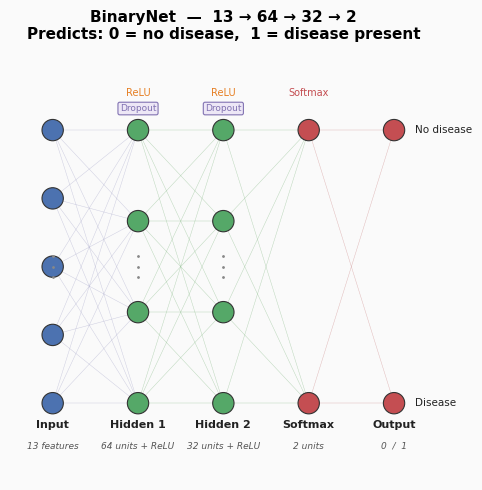

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1. BinaryNet   13 → 64 → 32 → 2
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.set_title('BinaryNet  —  13 → 64 → 32 → 2\n'
             'Predicts: 0 = no disease,  1 = disease present',
             fontsize=11, fontweight='bold', pad=10)

# Layer x-positions
xs = [0.10, 0.30, 0.50, 0.70, 0.90]

# Layer specs: (real_n, colour, label, sublabel, has_dropout)
spec_bin = [
    (13, 'input',  'Input',    '13 features',   False),
    (64, 'hidden', 'Hidden 1', '64 units + ReLU', True),
    (32, 'hidden', 'Hidden 2', '32 units + ReLU', True),
    ( 2, 'output', 'Softmax',  '2 units',         False),
    ( 2, 'output', 'Output',   '0  /  1',         False),
]

layer_ys = []
for i, (n, kind, lbl, sub, has_drop) in enumerate(spec_bin):
    n_shown = SHOW.get(n, 4)
    ys = neuron_positions(n_shown, xs[i], Y_TOP, Y_BOT)
    draw_layer(ax, xs[i], ys, radius=R, colour=NEURON_COLOURS[kind],
               real_n=n, show_dots=(n > n_shown))
    layer_label(ax, xs[i], Y_BOT, lbl, sub)
    if has_drop:
        dropout_badge(ax, xs[i], Y_TOP)
    layer_ys.append(ys)

# Connections
conn_colour = ['#AAAACC', '#88BB88', '#88BB88', '#CC8888']
for i in range(len(xs) - 1):
    draw_connections(ax, xs[i], layer_ys[i], xs[i + 1], layer_ys[i + 1],
                     colour=conn_colour[i])

# Activation label on arrows between hidden layers
for xi in xs[1:3]:
    ax.text(xi, Y_TOP + 0.08, 'ReLU', ha='center', fontsize=7, color='#E67E22')

ax.text(xs[3], Y_TOP + 0.08, 'Softmax', ha='center', fontsize=7, color='#C44E52')

# Output labels
for y, lbl in zip(layer_ys[-1], ['No disease', 'Disease']):
    ax.text(xs[-1] + 0.05, y, lbl, va='center', fontsize=7.5, color='#222222')

plt.tight_layout()
plt.savefig('binary_net_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

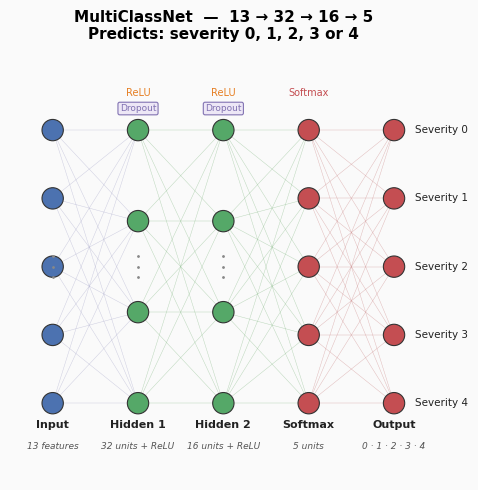

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2. MultiClassNet   13 → 32 → 16 → 5
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.set_title('MultiClassNet  —  13 → 32 → 16 → 5\n'
             'Predicts: severity 0, 1, 2, 3 or 4',
             fontsize=11, fontweight='bold', pad=10)

xs = [0.10, 0.30, 0.50, 0.70, 0.90]

spec_multi = [
    (13, 'input',  'Input',    '13 features',   False),
    (32, 'hidden', 'Hidden 1', '32 units + ReLU', True),
    (16, 'hidden', 'Hidden 2', '16 units + ReLU', True),
    ( 5, 'output', 'Softmax',  '5 units',         False),
    ( 5, 'output', 'Output',   '0 · 1 · 2 · 3 · 4', False),
]

layer_ys = []
for i, (n, kind, lbl, sub, has_drop) in enumerate(spec_multi):
    n_shown = SHOW.get(n, 4)
    ys = neuron_positions(n_shown, xs[i], Y_TOP, Y_BOT)
    draw_layer(ax, xs[i], ys, radius=R, colour=NEURON_COLOURS[kind],
               real_n=n, show_dots=(n > n_shown))
    layer_label(ax, xs[i], Y_BOT, lbl, sub)
    if has_drop:
        dropout_badge(ax, xs[i], Y_TOP)
    layer_ys.append(ys)

conn_colour = ['#AAAACC', '#88BB88', '#88BB88', '#CC8888']
for i in range(len(xs) - 1):
    draw_connections(ax, xs[i], layer_ys[i], xs[i + 1], layer_ys[i + 1],
                     colour=conn_colour[i])

for xi in xs[1:3]:
    ax.text(xi, Y_TOP + 0.08, 'ReLU', ha='center', fontsize=7, color='#E67E22')
ax.text(xs[3], Y_TOP + 0.08, 'Softmax', ha='center', fontsize=7, color='#C44E52')

output_labels = ['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3', 'Severity 4']
for y, lbl in zip(layer_ys[-1], output_labels):
    ax.text(xs[-1] + 0.05, y, lbl, va='center', fontsize=7.5, color='#222222')

plt.tight_layout()
plt.savefig('multiclass_net_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

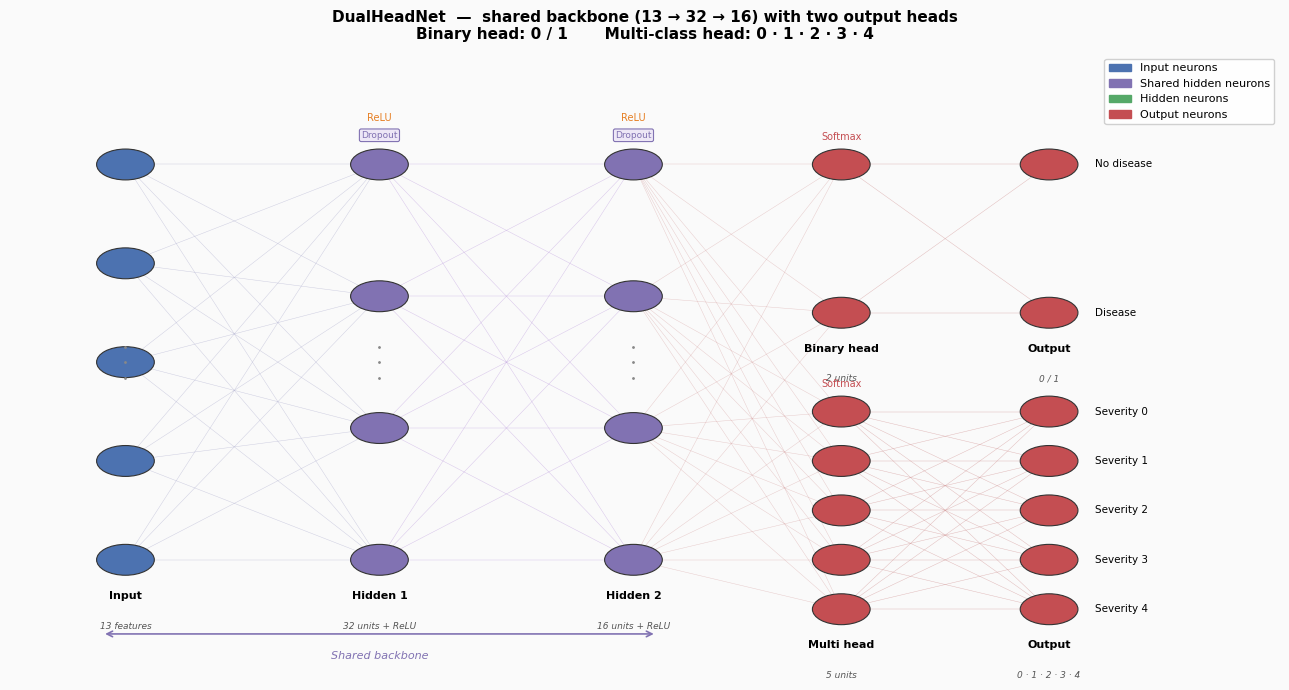

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3. DualHeadNet   13 → 32 → 16 ──┬── 2  (binary)
#                                  └── 5  (multi-class)
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 1.1)
ax.set_ylim(0, 1)
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.set_title('DualHeadNet  —  shared backbone (13 → 32 → 16) with two output heads\n'
             'Binary head: 0 / 1       Multi-class head: 0 · 1 · 2 · 3 · 4',
             fontsize=11, fontweight='bold', pad=10)

# ── Backbone (3 shared layers) ─────────────────────────────────────────────
xs_bb  = [0.10, 0.32, 0.54]
Y_MID  = 0.50                 # vertical centre for backbone
Y_SPAN = 0.32                 # half-span of neurons in backbone

backbone_spec = [
    (13, 'input',  'Input',    '13 features',   False),
    (32, 'shared', 'Hidden 1', '32 units + ReLU', True),
    (16, 'shared', 'Hidden 2', '16 units + ReLU', True),
]

bb_ys = []
for i, (n, kind, lbl, sub, has_drop) in enumerate(backbone_spec):
    n_shown = SHOW.get(n, 4)
    ys = neuron_positions(n_shown, xs_bb[i], Y_MID + Y_SPAN, Y_MID - Y_SPAN)
    draw_layer(ax, xs_bb[i], ys, radius=R, colour=NEURON_COLOURS[kind],
               real_n=n, show_dots=(n > n_shown))
    ax.text(xs_bb[i], Y_MID - Y_SPAN - 0.05, lbl,
            ha='center', va='top', fontsize=8, fontweight='bold')
    ax.text(xs_bb[i], Y_MID - Y_SPAN - 0.10, sub,
            ha='center', va='top', fontsize=6.5, style='italic', color='#555')
    if has_drop:
        dropout_badge(ax, xs_bb[i], Y_MID + Y_SPAN)
    if i > 0:
        ax.text(xs_bb[i], Y_MID + Y_SPAN + 0.07, 'ReLU',
                ha='center', fontsize=7, color='#E67E22')
    bb_ys.append(ys)

# Connections within backbone
draw_connections(ax, xs_bb[0], bb_ys[0], xs_bb[1], bb_ys[1], colour='#AAAACC')
draw_connections(ax, xs_bb[1], bb_ys[1], xs_bb[2], bb_ys[2], colour='#BB99DD')

# ── Binary head (top) ──────────────────────────────────────────────────────
x_fork = xs_bb[-1]
ys_fork = bb_ys[-1]

Y_TOP_H = 0.82
Y_BOT_H = 0.58
xs_bin = [0.72, 0.90]

head_bin_spec = [
    (2, 'output', 'Binary head', '2 units'),
    (2, 'output', 'Output',      '0 / 1'),
]

bin_ys = []
for i, (n, kind, lbl, sub) in enumerate(head_bin_spec):
    ys = neuron_positions(n, xs_bin[i], Y_TOP_H, Y_BOT_H)
    draw_layer(ax, xs_bin[i], ys, radius=R, colour=NEURON_COLOURS[kind])
    ax.text(xs_bin[i], Y_BOT_H - 0.05, lbl, ha='center', va='top',
            fontsize=8, fontweight='bold')
    ax.text(xs_bin[i], Y_BOT_H - 0.10, sub, ha='center', va='top',
            fontsize=6.5, style='italic', color='#555')
    bin_ys.append(ys)

# Fork connections: backbone → binary head
draw_connections(ax, x_fork, ys_fork, xs_bin[0], bin_ys[0], colour='#CC8888', alpha=0.4)
draw_connections(ax, xs_bin[0], bin_ys[0], xs_bin[1], bin_ys[1], colour='#CC8888')

ax.text(xs_bin[0], Y_TOP_H + 0.04, 'Softmax', ha='center', fontsize=7, color='#C44E52')

# Output labels
for y, lbl in zip(bin_ys[-1], ['No disease', 'Disease']):
    ax.text(xs_bin[-1] + 0.04, y, lbl, va='center', fontsize=7.5)

# ── Multi-class head (bottom) ──────────────────────────────────────────────
Y_TOP_M = 0.42
Y_BOT_M = 0.10
xs_mc = [0.72, 0.90]

head_mc_spec = [
    (5, 'output', 'Multi head', '5 units'),
    (5, 'output', 'Output',     '0 · 1 · 2 · 3 · 4'),
]

mc_ys = []
for i, (n, kind, lbl, sub) in enumerate(head_mc_spec):
    ys = neuron_positions(n, xs_mc[i], Y_TOP_M, Y_BOT_M)
    draw_layer(ax, xs_mc[i], ys, radius=R, colour=NEURON_COLOURS[kind])
    ax.text(xs_mc[i], Y_BOT_M - 0.05, lbl, ha='center', va='top',
            fontsize=8, fontweight='bold')
    ax.text(xs_mc[i], Y_BOT_M - 0.10, sub, ha='center', va='top',
            fontsize=6.5, style='italic', color='#555')
    mc_ys.append(ys)

draw_connections(ax, x_fork, ys_fork, xs_mc[0], mc_ys[0], colour='#CC8888', alpha=0.4)
draw_connections(ax, xs_mc[0], mc_ys[0], xs_mc[1], mc_ys[1], colour='#CC8888')

ax.text(xs_mc[0], Y_TOP_M + 0.04, 'Softmax', ha='center', fontsize=7, color='#C44E52')

severity_labels = ['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3', 'Severity 4']
for y, lbl in zip(mc_ys[-1], severity_labels):
    ax.text(xs_mc[-1] + 0.04, y, lbl, va='center', fontsize=7.5)

# ── Backbone label ─────────────────────────────────────────────────────────
brace_y = 0.06
ax.annotate('', xy=(xs_bb[-1] + 0.02, brace_y),
            xytext=(xs_bb[0] - 0.02, brace_y),
            arrowprops=dict(arrowstyle='<->', color='#8172B2', lw=1.2))
ax.text(np.mean(xs_bb), brace_y - 0.04, 'Shared backbone',
        ha='center', fontsize=8, color='#8172B2', style='italic')

# Legend
legend_items = [
    mpatches.Patch(color='#4C72B0', label='Input neurons'),
    mpatches.Patch(color='#8172B2', label='Shared hidden neurons'),
    mpatches.Patch(color='#55A868', label='Hidden neurons'),
    mpatches.Patch(color='#C44E52', label='Output neurons'),
]
ax.legend(handles=legend_items, loc='upper right', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('dual_head_net_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Full Neuron Diagrams — every neuron drawn
Every circle below is a real neuron. Connections are drawn between all neurons in adjacent layers (alpha is low so the density of lines conveys the fully-connected nature of each layer pair).

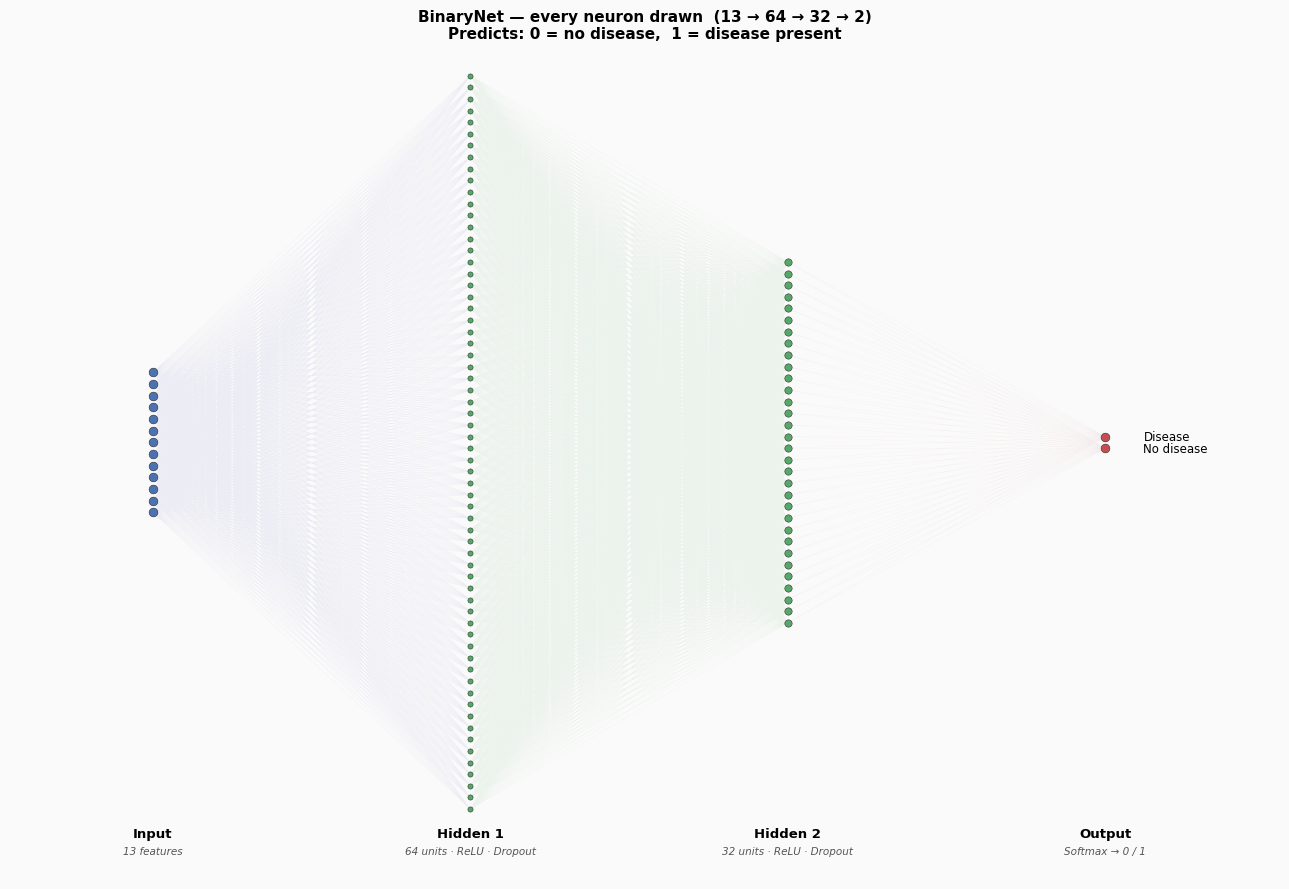

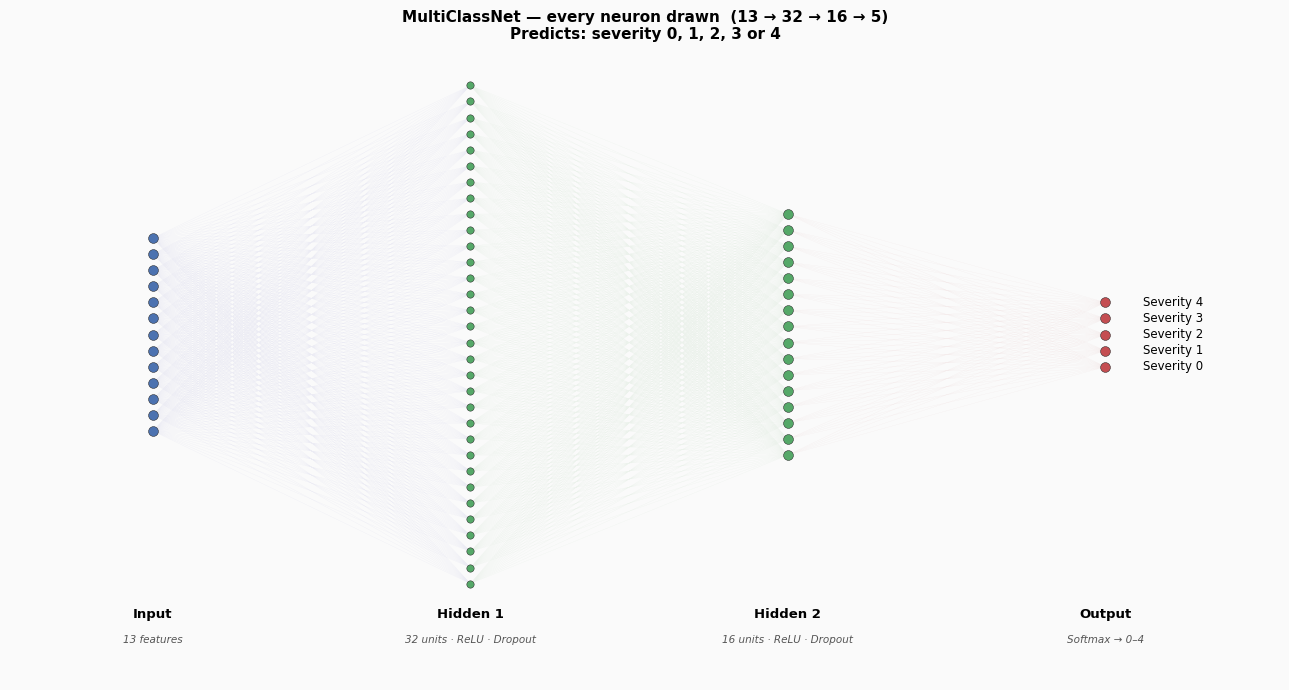

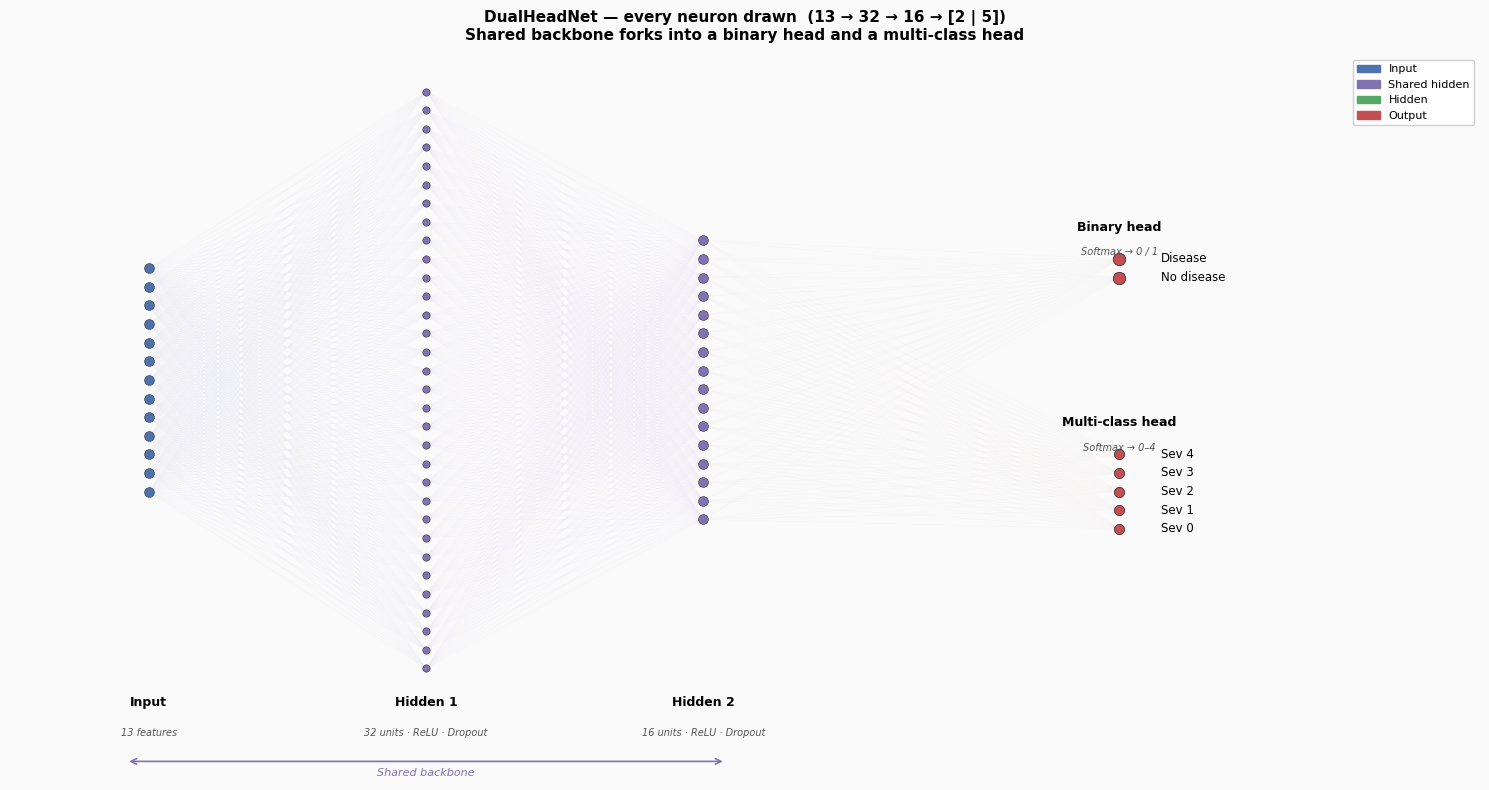

In [5]:
# ── Helpers for full-neuron diagrams ─────────────────────────────────────────

def full_pos(n, max_n):
    """y-positions for n neurons, centred within [0, max_n - 1]."""
    offset = (max_n - n) / 2.0
    return np.array([offset]) if n == 1 else np.linspace(offset, offset + n - 1, n)


def all_connections(ax, x1, ys1, x2, ys2, colour, lw=0.18, alpha=0.12):
    """Draw every neuron-to-neuron connection in one fast plot call."""
    sx, sy = [], []
    for y1 in ys1:
        for y2 in ys2:
            sx += [x1, x2, None]
            sy += [y1, y2, None]
    ax.plot(sx, sy, color=colour, lw=lw, alpha=alpha, zorder=1)


FC = {'input': '#4C72B0', 'hidden': '#55A868', 'output': '#C44E52', 'shared': '#8172B2'}


# ════════════════════════════════════════════════════════════════
# 1. BinaryNet  13 → 64 → 32 → 2
# ════════════════════════════════════════════════════════════════

MAX_N = 64  # tallest layer — all others are centred relative to this

fig, ax = plt.subplots(figsize=(13, 9))
ax.set_facecolor('#FAFAFA'); fig.patch.set_facecolor('#FAFAFA')
ax.axis('off')
ax.set_xlim(0.55, 4.55)
ax.set_ylim(-6, MAX_N + 1)
ax.set_title('BinaryNet — every neuron drawn  (13 → 64 → 32 → 2)\n'
             'Predicts: 0 = no disease,  1 = disease present',
             fontsize=11, fontweight='bold', pad=10)

layers_b = [
    (13, 'input',  'Input',     '13 features'),
    (64, 'hidden', 'Hidden 1',  '64 units · ReLU · Dropout'),
    (32, 'hidden', 'Hidden 2',  '32 units · ReLU · Dropout'),
    ( 2, 'output', 'Output',    'Softmax → 0 / 1'),
]
xs_b = [1, 2, 3, 4]
all_ys_b = []

for i, (n, kind, lbl, sub) in enumerate(layers_b):
    ys = full_pos(n, MAX_N)
    dot_s = max(8, min(40, 900 // n))           # smaller dots for larger layers
    ax.scatter([xs_b[i]] * n, ys, s=dot_s,
               c=FC[kind], edgecolors='#222222', linewidths=0.35, zorder=3)
    ax.text(xs_b[i], -1.5, lbl, ha='center', va='top', fontsize=9.5, fontweight='bold')
    ax.text(xs_b[i], -3.2, sub, ha='center', va='top', fontsize=7.5,
            color='#555555', style='italic')
    all_ys_b.append(ys)

for i, col in enumerate(['#8888CC', '#88BB88', '#CC8888']):
    all_connections(ax, xs_b[i], all_ys_b[i], xs_b[i + 1], all_ys_b[i + 1], col)

for y, lbl in zip(all_ys_b[-1], ['No disease', 'Disease']):
    ax.text(xs_b[-1] + 0.12, y, lbl, va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('binary_net_full_neurons.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════
# 2. MultiClassNet  13 → 32 → 16 → 5
# ════════════════════════════════════════════════════════════════

MAX_N = 32

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_facecolor('#FAFAFA'); fig.patch.set_facecolor('#FAFAFA')
ax.axis('off')
ax.set_xlim(0.55, 4.55)
ax.set_ylim(-6, MAX_N + 1)
ax.set_title('MultiClassNet — every neuron drawn  (13 → 32 → 16 → 5)\n'
             'Predicts: severity 0, 1, 2, 3 or 4',
             fontsize=11, fontweight='bold', pad=10)

layers_m = [
    (13, 'input',  'Input',    '13 features'),
    (32, 'hidden', 'Hidden 1', '32 units · ReLU · Dropout'),
    (16, 'hidden', 'Hidden 2', '16 units · ReLU · Dropout'),
    ( 5, 'output', 'Output',   'Softmax → 0–4'),
]
xs_m = [1, 2, 3, 4]
all_ys_m = []

for i, (n, kind, lbl, sub) in enumerate(layers_m):
    ys = full_pos(n, MAX_N)
    dot_s = max(10, min(50, 900 // n))
    ax.scatter([xs_m[i]] * n, ys, s=dot_s,
               c=FC[kind], edgecolors='#222222', linewidths=0.35, zorder=3)
    ax.text(xs_m[i], -1.5, lbl, ha='center', va='top', fontsize=9.5, fontweight='bold')
    ax.text(xs_m[i], -3.2, sub, ha='center', va='top', fontsize=7.5,
            color='#555555', style='italic')
    all_ys_m.append(ys)

for i, col in enumerate(['#8888CC', '#88BB88', '#CC8888']):
    all_connections(ax, xs_m[i], all_ys_m[i], xs_m[i + 1], all_ys_m[i + 1], col)

for y, lbl in zip(all_ys_m[-1],
                  ['Severity 0', 'Severity 1', 'Severity 2', 'Severity 3', 'Severity 4']):
    ax.text(xs_m[-1] + 0.12, y, lbl, va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('multiclass_net_full_neurons.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════
# 3. DualHeadNet  13 → 32 → 16 ──┬── 2  (binary head)
#                                 └── 5  (multi-class head)
# ════════════════════════════════════════════════════════════════

MAX_N = 32

fig, ax = plt.subplots(figsize=(15, 8))
ax.set_facecolor('#FAFAFA'); fig.patch.set_facecolor('#FAFAFA')
ax.axis('off')
ax.set_xlim(0.5, 5.8)
ax.set_ylim(-6, MAX_N + 1)
ax.set_title('DualHeadNet — every neuron drawn  (13 → 32 → 16 → [2 | 5])\n'
             'Shared backbone forks into a binary head and a multi-class head',
             fontsize=11, fontweight='bold', pad=10)

# Shared backbone
backbone = [
    (13, 'input',  'Input',    '13 features'),
    (32, 'shared', 'Hidden 1', '32 units · ReLU · Dropout'),
    (16, 'shared', 'Hidden 2', '16 units · ReLU · Dropout'),
]
xs_bb_f = [1, 2, 3]
bb_ys_f = []

for i, (n, kind, lbl, sub) in enumerate(backbone):
    ys = full_pos(n, MAX_N)
    dot_s = max(10, min(50, 900 // n))
    ax.scatter([xs_bb_f[i]] * n, ys, s=dot_s,
               c=FC[kind], edgecolors='#222222', linewidths=0.35, zorder=3)
    ax.text(xs_bb_f[i], -1.5, lbl, ha='center', va='top', fontsize=9, fontweight='bold')
    ax.text(xs_bb_f[i], -3.2, sub, ha='center', va='top', fontsize=7,
            color='#555555', style='italic')
    bb_ys_f.append(ys)

all_connections(ax, xs_bb_f[0], bb_ys_f[0], xs_bb_f[1], bb_ys_f[1], '#8888CC')
all_connections(ax, xs_bb_f[1], bb_ys_f[1], xs_bb_f[2], bb_ys_f[2], '#AA88DD')

x_fork = xs_bb_f[-1]
ys_fork = bb_ys_f[-1]

# Binary head (top half)
y_bin  = full_pos(2, MAX_N) + 6    # shift upward
x_bin  = 4.5
ax.scatter([x_bin] * 2, y_bin, s=80, c=FC['output'],
           edgecolors='#222', linewidths=0.5, zorder=3)
ax.text(x_bin, y_bin.max() + 1.5, 'Binary head', ha='center',
        fontsize=9, fontweight='bold')
ax.text(x_bin, y_bin.max() + 0.2, 'Softmax → 0 / 1', ha='center',
        fontsize=7, color='#555', style='italic')
all_connections(ax, x_fork, ys_fork, x_bin, y_bin, '#CC8888', alpha=0.09)
for y, lbl in zip(y_bin, ['No disease', 'Disease']):
    ax.text(x_bin + 0.15, y, lbl, va='center', fontsize=8.5)

# Multi-class head (bottom half)
y_mc  = full_pos(5, MAX_N) - 6    # shift downward
x_mc  = 4.5
ax.scatter([x_mc] * 5, y_mc, s=55, c=FC['output'],
           edgecolors='#222', linewidths=0.5, zorder=3)
ax.text(x_mc, y_mc.max() + 1.5, 'Multi-class head', ha='center',
        fontsize=9, fontweight='bold')
ax.text(x_mc, y_mc.max() + 0.2, 'Softmax → 0–4', ha='center',
        fontsize=7, color='#555', style='italic')
all_connections(ax, x_fork, ys_fork, x_mc, y_mc, '#CC8888', alpha=0.09)
for y, lbl in zip(y_mc, ['Sev 0', 'Sev 1', 'Sev 2', 'Sev 3', 'Sev 4']):
    ax.text(x_mc + 0.15, y, lbl, va='center', fontsize=8.5)

# Backbone brace label
ax.annotate('', xy=(xs_bb_f[-1] + 0.08, -5), xytext=(xs_bb_f[0] - 0.08, -5),
            arrowprops=dict(arrowstyle='<->', color='#8172B2', lw=1.2))
ax.text(np.mean(xs_bb_f), -5.8, 'Shared backbone',
        ha='center', fontsize=8, color='#8172B2', style='italic')

# Legend
items = [mpatches.Patch(color=FC['input'],  label='Input'),
         mpatches.Patch(color=FC['shared'], label='Shared hidden'),
         mpatches.Patch(color=FC['hidden'], label='Hidden'),
         mpatches.Patch(color=FC['output'], label='Output')]
ax.legend(handles=items, loc='upper right', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('dual_head_net_full_neurons.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Block Diagrams — layers as scaled rectangles
Each rectangle represents one layer. **Height is proportional to the number of neurons** in that layer, so you can visually compare layer widths at a glance.

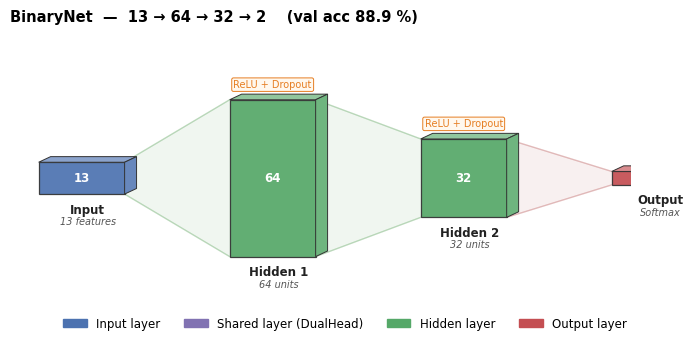

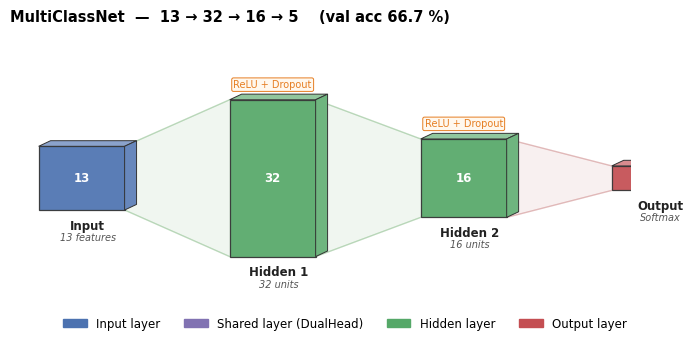

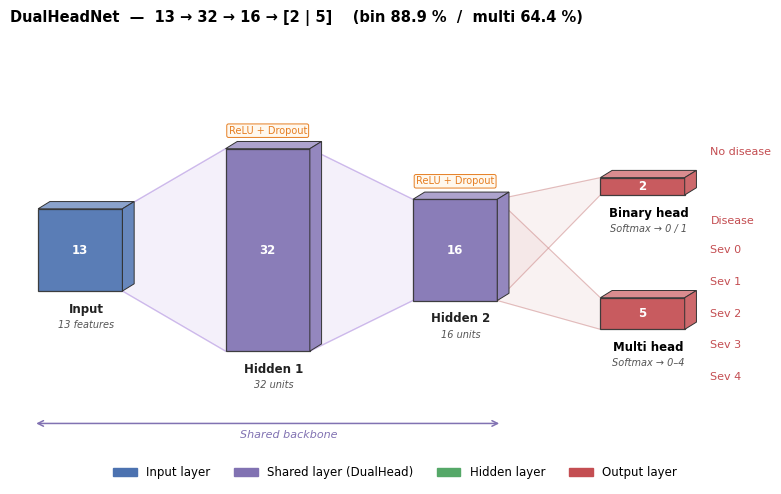

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Block diagram helpers ─────────────────────────────────────────────────────

BLK_W   = 0.18   # fixed block width
MAX_H   = 0.70   # height of the tallest layer (normalised to this)
GAP_X   = 0.22   # horizontal gap between block centres
EDGE_C  = '#333333'

BCOL = {
    'input':  '#4C72B0',
    'hidden': '#55A868',
    'output': '#C44E52',
    'shared': '#8172B2',
}


def block_height(n, max_n):
    """Scale block height proportionally to neuron count."""
    return max(0.06, MAX_H * (n / max_n))


def draw_block(ax, cx, n, max_n, kind, label, sublabel, depth=0.025):
    """Draw a 3-D-style layer block centred at cx, vertically centred."""
    h = block_height(n, max_n)
    colour = BCOL[kind]
    x0, y0 = cx - BLK_W / 2, -h / 2

    # ── front face ────────────────────────────────────────────────
    front = mpatches.FancyBboxPatch(
        (x0, y0), BLK_W, h,
        boxstyle='square,pad=0',
        facecolor=colour, edgecolor=EDGE_C, linewidth=0.9,
        alpha=0.92, zorder=3,
    )
    ax.add_patch(front)

    # ── top face (parallelogram) ───────────────────────────────────
    top_x = [x0,          x0 + BLK_W,          x0 + BLK_W + depth, x0 + depth,          x0]
    top_y = [y0 + h,      y0 + h,              y0 + h + depth,      y0 + h + depth,      y0 + h]
    ax.fill(top_x, top_y,
            facecolor=_lighten(colour, 0.35), edgecolor=EDGE_C, lw=0.7, zorder=4)

    # ── right face (parallelogram) ─────────────────────────────────
    rgt_x = [x0 + BLK_W, x0 + BLK_W + depth, x0 + BLK_W + depth, x0 + BLK_W, x0 + BLK_W]
    rgt_y = [y0,          y0 + depth,          y0 + h + depth,      y0 + h,      y0]
    ax.fill(rgt_x, rgt_y,
            facecolor=_lighten(colour, 0.15), edgecolor=EDGE_C, lw=0.7, zorder=4)

    # ── neuron count inside front face ────────────────────────────
    ax.text(cx, 0, str(n),
            ha='center', va='center', fontsize=8.5,
            fontweight='bold', color='white', zorder=5)

    # ── labels below ──────────────────────────────────────────────
    ax.text(cx + depth / 2, y0 - 0.04, label,
            ha='center', va='top', fontsize=8.5, fontweight='bold', color='#222')
    ax.text(cx + depth / 2, y0 - 0.10, sublabel,
            ha='center', va='top', fontsize=7, color='#555', style='italic')

    # return right-edge x for connecting arrow
    return cx + BLK_W / 2


def _lighten(hex_col, amount):
    """Return a lightened version of a hex colour."""
    hex_col = hex_col.lstrip('#')
    r, g, b = [int(hex_col[i:i+2], 16) / 255 for i in (0, 2, 4)]
    r = r + (1 - r) * amount
    g = g + (1 - g) * amount
    b = b + (1 - b) * amount
    return (r, g, b)


def connect_blocks(ax, x_right, cx_next, n_left, n_right, max_n, colour='#888', lw=1.0):
    """Draw a trapezoid fan between two adjacent blocks."""
    h_l = block_height(n_left,  max_n) / 2
    h_r = block_height(n_right, max_n) / 2
    x_l  = x_right
    x_r  = cx_next - BLK_W / 2
    poly_x = [x_l,  x_l,  x_r,  x_r]
    poly_y = [-h_l, h_l, h_r, -h_r]
    ax.fill(poly_x, poly_y, alpha=0.12, color=colour, zorder=2)
    ax.plot([x_l, x_r], [ h_l,  h_r], color=colour, lw=lw, alpha=0.5, zorder=2)
    ax.plot([x_l, x_r], [-h_l, -h_r], color=colour, lw=lw, alpha=0.5, zorder=2)


def activation_label(ax, cx, n, max_n, text, colour='#E67E22'):
    h = block_height(n, max_n) / 2
    ax.text(cx, h + 0.045, text, ha='center', va='bottom',
            fontsize=7, color=colour,
            bbox=dict(boxstyle='round,pad=0.18', fc='#FFF8EE', ec=colour, lw=0.7))


# ── Build one network's block diagram ─────────────────────────────────────────

def block_diagram(ax, title, layers, max_n, start_x=0.15, depth=0.025):
    """
    layers : list of (n_neurons, kind, label, sublabel, activation_text_or_None)
    Returns the right-edge x of the last block.
    """
    ax.set_title(title, fontsize=10.5, fontweight='bold', loc='left', pad=8)
    ax.axis('off')
    ax.set_facecolor('none')

    cx = start_x
    prev_n    = None
    prev_xr   = None
    block_xs  = []

    for n, kind, lbl, sub, act in layers:
        xr = draw_block(ax, cx, n, max_n, kind, lbl, sub, depth=depth)
        if act:
            activation_label(ax, cx, n, max_n, act)
        if prev_n is not None:
            c = {'input': '#8888CC', 'hidden': '#88BB88',
                 'shared': '#AA88DD', 'output': '#CC8888'}[kind]
            connect_blocks(ax, prev_xr, cx, prev_n, n, max_n, colour=c)
        block_xs.append(cx)
        prev_n  = n
        prev_xr = xr
        cx += GAP_X + BLK_W

    return cx, block_xs


legend_items = [
    mpatches.Patch(color=BCOL['input'],  label='Input layer'),
    mpatches.Patch(color=BCOL['shared'], label='Shared layer (DualHead)'),
    mpatches.Patch(color=BCOL['hidden'], label='Hidden layer'),
    mpatches.Patch(color=BCOL['output'], label='Output layer'),
]

# ═════════════════════════════════════════════════════════════════════
# 1. BinaryNet  13 → 64 → 32 → 2
# ═════════════════════════════════════════════════════════════════════

fig1, ax = plt.subplots(1, 1, figsize=(7, 3.5))
fig1.patch.set_alpha(0)
ax.set_xlim(0, 1.3); ax.set_ylim(-0.55, 0.65)

block_diagram(ax,
    title='BinaryNet  —  13 → 64 → 32 → 2    (val acc 88.9 %)',
    layers=[
        (13, 'input',  'Input',    '13 features',              None),
        (64, 'hidden', 'Hidden 1', '64 units',                 'ReLU + Dropout'),
        (32, 'hidden', 'Hidden 2', '32 units',                 'ReLU + Dropout'),
        ( 2, 'output', 'Output',   'Softmax',                  None),
    ],
    max_n=64,
)
for dy, lbl in zip([0.12, -0.12], ['No disease', 'Disease']):
    ax.annotate(lbl, xy=(0.15 + 3 * (GAP_X + BLK_W) + BLK_W / 2 + 0.025, dy),
                fontsize=8, va='center', color='#C44E52')

fig1.legend(handles=legend_items, loc='lower center', ncol=4,
            fontsize=8.5, framealpha=0, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('binary_net_block_diagram.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

# ═════════════════════════════════════════════════════════════════════
# 2. MultiClassNet  13 → 32 → 16 → 5
# ═════════════════════════════════════════════════════════════════════

fig2, ax = plt.subplots(1, 1, figsize=(7, 3.5))
fig2.patch.set_alpha(0)
ax.set_xlim(0, 1.3); ax.set_ylim(-0.55, 0.65)

block_diagram(ax,
    title='MultiClassNet  —  13 → 32 → 16 → 5    (val acc 66.7 %)',
    layers=[
        (13, 'input',  'Input',    '13 features',  None),
        (32, 'hidden', 'Hidden 1', '32 units',      'ReLU + Dropout'),
        (16, 'hidden', 'Hidden 2', '16 units',      'ReLU + Dropout'),
        ( 5, 'output', 'Output',   'Softmax',        None),
    ],
    max_n=32,
)
fig2.legend(handles=legend_items, loc='lower center', ncol=4,
            fontsize=8.5, framealpha=0, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('multiclass_net_block_diagram.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

# ═════════════════════════════════════════════════════════════════════
# 3. DualHeadNet  13 → 32 → 16 → [2 | 5]
# ═════════════════════════════════════════════════════════════════════

fig3, ax = plt.subplots(1, 1, figsize=(8, 5))
fig3.patch.set_alpha(0)
ax.set_xlim(0, 1.6); ax.set_ylim(-0.65, 0.75)
ax.axis('off')
ax.set_facecolor('none')
ax.set_title('DualHeadNet  —  13 → 32 → 16 → [2 | 5]    '
             '(bin 88.9 %  /  multi 64.4 %)',
             fontsize=10.5, fontweight='bold', loc='left', pad=8)

DEPTH = 0.025
MAX_N_D = 32

# Backbone
bb_layers = [
    (13, 'input',  'Input',    '13 features', None),
    (32, 'shared', 'Hidden 1', '32 units',    'ReLU + Dropout'),
    (16, 'shared', 'Hidden 2', '16 units',    'ReLU + Dropout'),
]
cx = 0.15
prev_n, prev_xr = None, None
for n, kind, lbl, sub, act in bb_layers:
    xr = draw_block(ax, cx, n, MAX_N_D, kind, lbl, sub, depth=DEPTH)
    if act:
        activation_label(ax, cx, n, MAX_N_D, act)
    if prev_n:
        connect_blocks(ax, prev_xr, cx, prev_n, n, MAX_N_D, colour='#AA88DD')
    prev_n, prev_xr = n, xr
    cx += GAP_X + BLK_W

fork_xr = prev_xr   # right edge of last shared block
fork_n  = prev_n

# Binary head  (upper)
Y_BIN = 0.22
cx_bin = cx

def draw_block_at_y(ax, cx, cy, n, max_n, kind, label, sublabel, depth=0.025):
    h = block_height(n, max_n)
    colour = BCOL[kind]
    x0, y0 = cx - BLK_W / 2, cy - h / 2
    front = mpatches.FancyBboxPatch((x0, y0), BLK_W, h,
        boxstyle='square,pad=0', facecolor=colour,
        edgecolor=EDGE_C, lw=0.9, alpha=0.92, zorder=3)
    ax.add_patch(front)
    top_x = [x0, x0+BLK_W, x0+BLK_W+depth, x0+depth, x0]
    top_y = [y0+h, y0+h, y0+h+depth, y0+h+depth, y0+h]
    ax.fill(top_x, top_y, facecolor=_lighten(colour, 0.35), edgecolor=EDGE_C, lw=0.7, zorder=4)
    rgt_x = [x0+BLK_W, x0+BLK_W+depth, x0+BLK_W+depth, x0+BLK_W, x0+BLK_W]
    rgt_y = [y0, y0+depth, y0+h+depth, y0+h, y0]
    ax.fill(rgt_x, rgt_y, facecolor=_lighten(colour, 0.15), edgecolor=EDGE_C, lw=0.7, zorder=4)
    ax.text(cx, cy, str(n), ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white', zorder=5)
    ax.text(cx+depth/2, y0-0.04, label,   ha='center', va='top', fontsize=8.5, fontweight='bold')
    ax.text(cx+depth/2, y0-0.10, sublabel, ha='center', va='top', fontsize=7, color='#555', style='italic')
    return cx + BLK_W / 2, h


for n_h, lbl_h, sub_h in [(2, 'Binary head', 'Softmax → 0 / 1')]:
    xr_h, h_h = draw_block_at_y(ax, cx_bin, Y_BIN, n_h, MAX_N_D, 'output', lbl_h, sub_h)
    h_fork = block_height(fork_n, MAX_N_D) / 2
    h_head = h_h / 2
    poly_x = [fork_xr, fork_xr, cx_bin - BLK_W/2, cx_bin - BLK_W/2]
    poly_y = [-h_fork, h_fork, Y_BIN + h_head, Y_BIN - h_head]
    ax.fill(poly_x, poly_y, alpha=0.10, color='#CC8888', zorder=2)
    for sign in [1, -1]:
        ax.plot([fork_xr, cx_bin - BLK_W/2],
                [sign * h_fork, Y_BIN + sign * h_head],
                color='#CC8888', lw=0.8, alpha=0.5, zorder=2)
    for dy, lbl in zip([0.12, -0.12], ['No disease', 'Disease']):
        ax.text(xr_h + DEPTH + 0.03, Y_BIN + dy, lbl,
                va='center', fontsize=8, color='#C44E52')

# Multi-class head  (lower)
Y_MC = -0.22
for n_h, lbl_h, sub_h in [(5, 'Multi head', 'Softmax → 0–4')]:
    xr_h, h_h = draw_block_at_y(ax, cx_bin, Y_MC, n_h, MAX_N_D, 'output', lbl_h, sub_h)
    h_fork = block_height(fork_n, MAX_N_D) / 2
    h_head = h_h / 2
    poly_x = [fork_xr, fork_xr, cx_bin - BLK_W/2, cx_bin - BLK_W/2]
    poly_y = [-h_fork, h_fork, Y_MC + h_head, Y_MC - h_head]
    ax.fill(poly_x, poly_y, alpha=0.10, color='#CC8888', zorder=2)
    for sign in [1, -1]:
        ax.plot([fork_xr, cx_bin - BLK_W/2],
                [sign * h_fork, Y_MC + sign * h_head],
                color='#CC8888', lw=0.8, alpha=0.5, zorder=2)
    for dy, lbl in zip([0.22, 0.11, 0, -0.11, -0.22],
                        ['Sev 0', 'Sev 1', 'Sev 2', 'Sev 3', 'Sev 4']):
        ax.text(xr_h + DEPTH + 0.03, Y_MC + dy, lbl,
                va='center', fontsize=8, color='#C44E52')

# Shared backbone brace
brace_y = -0.60
ax.annotate('', xy=(fork_xr + 0.01, brace_y),
            xytext=(0.15 - BLK_W/2 - 0.01, brace_y),
            arrowprops=dict(arrowstyle='<->', color='#8172B2', lw=1.1))
ax.text((0.15 + fork_xr) / 2, brace_y - 0.05, 'Shared backbone',
        ha='center', fontsize=8, color='#8172B2', style='italic')

fig3.legend(handles=legend_items, loc='lower center', ncol=4,
            fontsize=8.5, framealpha=0, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('dual_head_net_block_diagram.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()
